# Customer Intelligence System

### Note

Since the Country Dataset does not contain a target column for classification, the Bank Marketing Dataset was used for implementing both clustering and classification techniques as permitted by the mentor.

## Step 1: Import Libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

### Observation

The required libraries for data preprocessing, visualization, clustering, dimensionality reduction, and machine learning were imported successfully.

## Step 2: Load Dataset

In [74]:
df = pd.read_csv("bank.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


### Observation

The dataset was loaded successfully and contains 11,162 customer records with 17 columns. It includes customer information such as age, job, education, balance, loan status, and deposit subscription details. The 'deposit' column can be used as the target variable for classification tasks.

## Step 3: Dataset Information

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


### Observation

The dataset contains 11,162 customer records and 17 columns. There are 7 numerical features and 10 categorical features. All columns have complete data with no missing values, making the dataset suitable for further preprocessing and machine learning tasks.

## Step 4: Missing Values Check

In [76]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


### Observation

The missing values check shows that all columns contain 0 missing values. This means the dataset is complete and no missing value treatment is required before further analysis.

## Step 5: Data Cleaning

In [77]:
df.columns = df.columns.str.strip()

df.drop_duplicates(inplace=True)

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (11162, 17)


### Observation

The data cleaning process was completed successfully. The dataset shape remained (11162, 17), indicating that there were no duplicate records and the column names were already clean and properly formatted.

## Step 6: Feature Encoding

In [78]:

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,0,1,1,0,2343,1,0,2,5,8,1042,1,-1,0,3,1
1,56,0,1,1,0,45,0,0,2,5,8,1467,1,-1,0,3,1
2,41,9,1,1,0,1270,1,0,2,5,8,1389,1,-1,0,3,1
3,55,7,1,1,0,2476,1,0,2,5,8,579,1,-1,0,3,1
4,54,0,1,2,0,184,0,0,2,5,8,673,2,-1,0,3,1


### Observation

All categorical columns were converted into numerical values using Label Encoding. This transformation allows machine learning algorithms to process the data effectively since most models require numerical input features.

## Step 7: Feature Scaling

In [79]:
X = df.drop('deposit', axis=1)
y = df['deposit']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)

Scaled Data Shape: (11162, 16)


### Observation

The dataset was successfully standardized using StandardScaler. After scaling, all features are on a similar scale, which helps improve the performance of clustering and classification algorithms. The transformed dataset contains 11,162 records and 16 input features.

## Step 8: Elbow Method

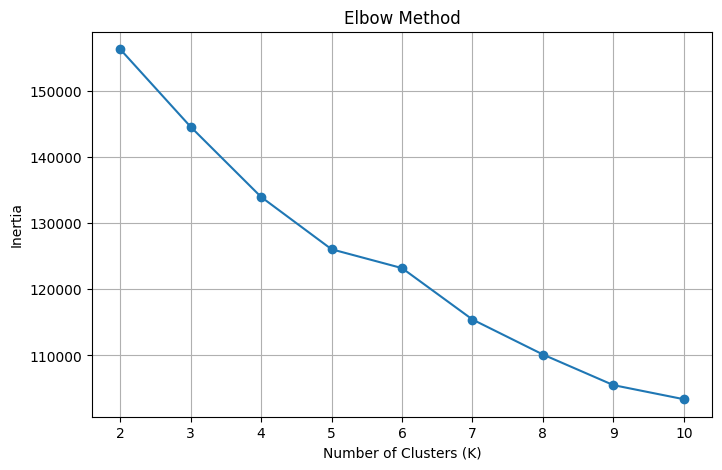

In [80]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

### Observation

From the Elbow Method graph, the inertia decreases rapidly up to K=5 and then starts reducing more slowly. Therefore, K=5 is selected as the optimal number of clusters for K-Means clustering.

## Step 9: K-Means Clustering

In [81]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("Cluster Counts:")
print(df['Cluster'].value_counts().sort_index())

Cluster Counts:
Cluster
0    5187
1    2453
2    2158
3     168
4    1196
Name: count, dtype: int64


### Observation

→ K-Means divided the customers into 5 clusters.

→ Cluster 0 contains the highest number of customers (5187).

→ Cluster 3 contains the lowest number of customers (168).

→ This shows that customers can be grouped into different segments based on their banking and personal details.

## Step 10: Silhouette Score

In [82]:
score = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", round(score,3))

Silhouette Score: 0.138


### Observation

→ The Silhouette Score obtained is 0.138.

→ The positive score indicates that meaningful clusters were formed.

→ Some overlap exists between clusters, which is common in real-world customer datasets.

→ Overall, the clustering model was able to group customers into different segments.

## Step 11: DBSCAN Clustering

In [83]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)

dbscan_clusters = dbscan.fit_predict(X_scaled)

print("Unique DBSCAN Clusters:")
print(np.unique(dbscan_clusters))

print("\nCluster Counts:")
print(pd.Series(dbscan_clusters).value_counts().sort_index())

Unique DBSCAN Clusters:
[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65]

Cluster Counts:
-1     4291
 0     1766
 1      849
 2      135
 3     1780
       ... 
 61       8
 62       4
 63       4
 64       6
 65       5
Name: count, Length: 67, dtype: int64


### Observation

→ DBSCAN identified multiple customer groups based on density.

→ Customers labeled as -1 are considered noise or outliers.

→ A large number of customers were assigned to different clusters, showing diverse customer behavior.

→ DBSCAN was able to detect customer segments without specifying the number of clusters beforehand.


## Step 12: PCA Visualization

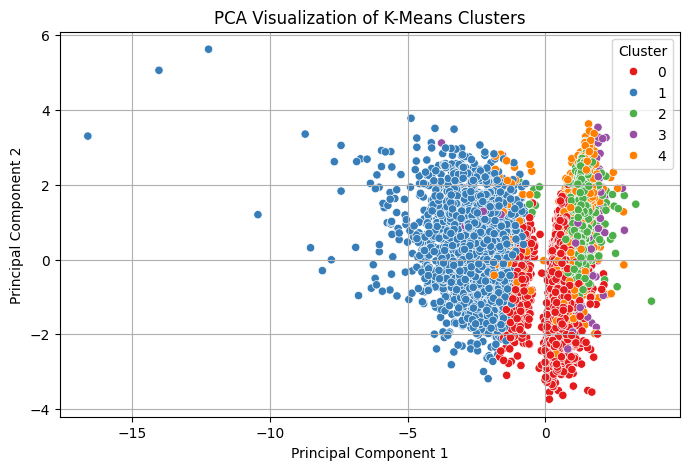

In [84]:


pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)

plt.show()

### Observation

→ PCA reduced the dataset into two dimensions for visualization.

→ Five customer clusters can be observed in the scatter plot.

→ Some clusters overlap, indicating similar customer characteristics.

→ The visualization confirms that K-Means successfully segmented customers into different groups.

## Step 13: Cluster Analysis

In [85]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)

cluster_summary

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
Cluster,,,,,,,,,,,,,,,,,
0,41.254482,4.821477,1.228456,1.366686,0.0,1665.787739,0.345479,0.000193,0.062657,16.101407,4.443031,386.899171,2.581839,4.599576,0.091190,2.939464,0.527665
1,41.743172,4.557684,1.246637,1.359152,0.0,1806.932735,0.490012,0.083979,0.086832,14.229515,5.847941,347.576845,1.918467,219.746025,3.518549,0.804729,0.644925
2,41.247451,3.943003,1.139018,1.102410,0.0,1400.898054,0.715014,0.000000,1.906858,15.675626,7.288693,361.119555,2.759500,-0.645505,0.006951,2.995829,0.242354
3,40.130952,4.303571,1.125000,1.220238,1.0,-61.803571,0.517857,0.339286,0.726190,16.839286,5.470238,344.589286,3.190476,19.410714,0.178571,2.821429,0.309524
4,40.212375,3.907191,1.095318,1.118729,0.0,816.007525,0.549331,1.000000,0.577759,16.467391,5.640468,380.899666,2.851171,6.845318,0.120401,2.923913,0.330268


### Observation

→ The average values of features were calculated for each cluster.

→ Different clusters show different customer characteristics such as balance, loan status, campaign details, and deposit behavior.

→ Cluster 1 has the highest average deposit value among all clusters.

→ The cluster summary helps understand the behavior of each customer segment.

# Classification using Random Forest and XGBoost

## Step 14: Train-Test Split

In [86]:
X = df.drop(['deposit', 'Cluster'], axis=1)
y = df['deposit']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (8929, 16)
Testing Data Shape: (2233, 16)


Observation

The dataset was split into training and testing sets. A total of 8,929 records were used for training and 2,233 records were used for testing. The target column (deposit) was separated from the input features before model training.

## Step 15: Random Forest Classification

In [87]:

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(accuracy,4))

cm = confusion_matrix(y_test, rf_pred)

print(cm)
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8334
[[952 214]
 [158 909]]
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



Observation

The Random Forest model achieved an accuracy of 83.34%. The confusion matrix and classification report indicate that most customer records were classified correctly, showing good predictive performance.

## Step 16: XGBoost Classification

In [88]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", round(xgb_accuracy, 4))
print(confusion_matrix(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.8424
[[961 205]
 [147 920]]
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      1166
           1       0.82      0.86      0.84      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233



Observation

The XGBoost model achieved an accuracy of 84.24%. The confusion matrix and classification report show that the model classified most customer records correctly, demonstrating strong classification performance.

## Step 17: Model Comparison

In [89]:
print("Random Forest Accuracy :", round(accuracy, 4))
print("XGBoost Accuracy       :", round(xgb_accuracy, 4))

Random Forest Accuracy : 0.8334
XGBoost Accuracy       : 0.8424


Observation

XGBoost achieved a slightly higher accuracy (84.24%) than Random Forest (83.34%). Therefore, XGBoost was selected as the better-performing classification model for this dataset.

#Conclusion

This project applied clustering and classification techniques on the Bank Marketing dataset.

K-Means and DBSCAN were used to identify customer segments, while Random Forest and XGBoost were used for deposit prediction.

Both classification models achieved good performance, with XGBoost achieving the highest accuracy of 84.24%.

Overall, machine learning techniques helped analyze customer behavior and support better marketing decisions.